In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/playground-series-s5e12/sample_submission.csv
/kaggle/input/competitions/playground-series-s5e12/train.csv
/kaggle/input/competitions/playground-series-s5e12/test.csv


In [2]:
pip install pykan xgboost scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.1/78.1 kB 3.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

train=pd.read_csv("/kaggle/input/competitions/playground-series-s5e12/train.csv")
test=pd.read_csv("/kaggle/input/competitions/playground-series-s5e12/test.csv")
train.head()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
0,0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,...,Female,Hispanic,Highschool,Lower-Middle,Current,Employed,0,0,0,1.0
1,1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,...,Female,White,Highschool,Upper-Middle,Never,Employed,0,0,0,1.0
2,2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,...,Male,Hispanic,Highschool,Lower-Middle,Never,Retired,0,0,0,0.0
3,3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,...,Female,White,Highschool,Lower-Middle,Current,Employed,0,1,0,1.0
4,4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,...,Male,White,Highschool,Upper-Middle,Never,Retired,0,1,0,1.0


In [4]:
#check for missing value in both train and test set.
print('-----------------------')
print('Train set null number')
print(train.isnull().sum())
print('-----------------------')
print('Test set null number')
print(test.isnull().sum())
print('-----------------------')

-----------------------
Train set null number
id                                    0
age                                   0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
smoking_status                        0
employment_status                     0
family_history_diabetes               0
hypertension_history              

looking good, no missing value.
Next is to check for outlier
Delete it if it is a multivariate outlier?

In [5]:
data = train
data = data.drop(columns='id')
data.describe()

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
count,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000
mean,50.359734,2.072411,80.230803,5.963695,7.002200,6.012733,25.874684,0.858766,116.294193,75.440924,70.167749,186.818801,53.823214,102.905854,123.081850,0.149401,0.181990,0.030324,0.623296
std,11.655520,1.048189,51.195071,1.463336,0.901907,2.022707,2.860705,0.037980,11.010390,6.825775,6.938722,16.730832,8.266545,19.022416,24.739397,0.356484,0.385837,0.171478,0.484560
min,19.000000,1.000000,1.000000,0.100000,3.100000,0.600000,15.100000,0.680000,91.000000,51.000000,42.000000,117.000000,21.000000,51.000000,31.000000,0.000000,0.000000,0.000000,0.000000
25%,42.000000,1.000000,49.000000,5.000000,6.400000,4.600000,23.900000,0.830000,108.000000,71.000000,65.000000,175.000000,48.000000,89.000000,106.000000,0.000000,0.000000,0.000000,0.000000
50%,50.000000,2.000000,71.000000,6.000000,7.000000,6.000000,25.900000,0.860000,116.000000,75.000000,70.000000,187.000000,54.000000,103.000000,123.000000,0.000000,0.000000,0.000000,1.000000
75%,58.000000,3.000000,96.000000,7.000000,7.600000,7.400000,27.800000,0.880000,124.000000,80.000000,75.000000,199.000000,59.000000,116.000000,139.000000,0.000000,0.000000,0.000000,1.000000
max,89.000000,9.000000,747.000000,9.900000,9.900000,16.500000,38.400000,1.050000,163.000000,104.000000,101.000000,289.000000,90.000000,205.000000,290.000000,1.000000,1.000000,1.000000,1.000000


The Rule of Thumb
Z-score > 3: Moderately unusual (top 0.15% of data).
Z-score > 4 or 5: Highly unusual (Potential Outlier).
Z-score > 10: Extremely rare (Likely Data Error or Extreme Case).
Warning about Z-Scores
Z-scores assume your data is Normally Distributed (Bell Curve).

Works great for: Height, Weight, BMI, Blood Pressure.
Works poorly for: Skewed data like alcohol_consumption or physical_activity (where most people do 0-60 mins, but some super-athletes do 600).
For the skewed columns (like physical activity), a Z-score of 5 might actually be a valid data point (a marathon runner), not an error. For those, the IQR (Box plot method) is usually safer.

In [6]:

from scipy import stats


# 1. Select numeric columns
num_cols = ['age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week',
            'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi', 
            'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 
            'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides']

# 2. Calculate Z-scores
# This creates a new dataframe where every value is replaced by its Z-score
df_zscore = data[num_cols].apply(stats.zscore)

# 3. Check the max Z-score for each column to see how extreme they get
print(df_zscore.max().sort_values(ascending=False))


physical_activity_minutes_per_week    13.024099
triglycerides                          6.747063
alcohol_consumption_per_week           6.609105
cholesterol_total                      6.107363
ldl_cholesterol                        5.367048
screen_time_hours_per_day              5.184771
waist_to_hip_ratio                     5.035148
heart_rate                             4.443509
bmi                                    4.378406
hdl_cholesterol                        4.376291
systolic_bp                            4.241979
diastolic_bp                           4.184008
age                                    3.315192
sleep_hours_per_day                    3.212973
diet_score                             2.689954
dtype: float64


Visualize the Z-Scores (The Heatmap)

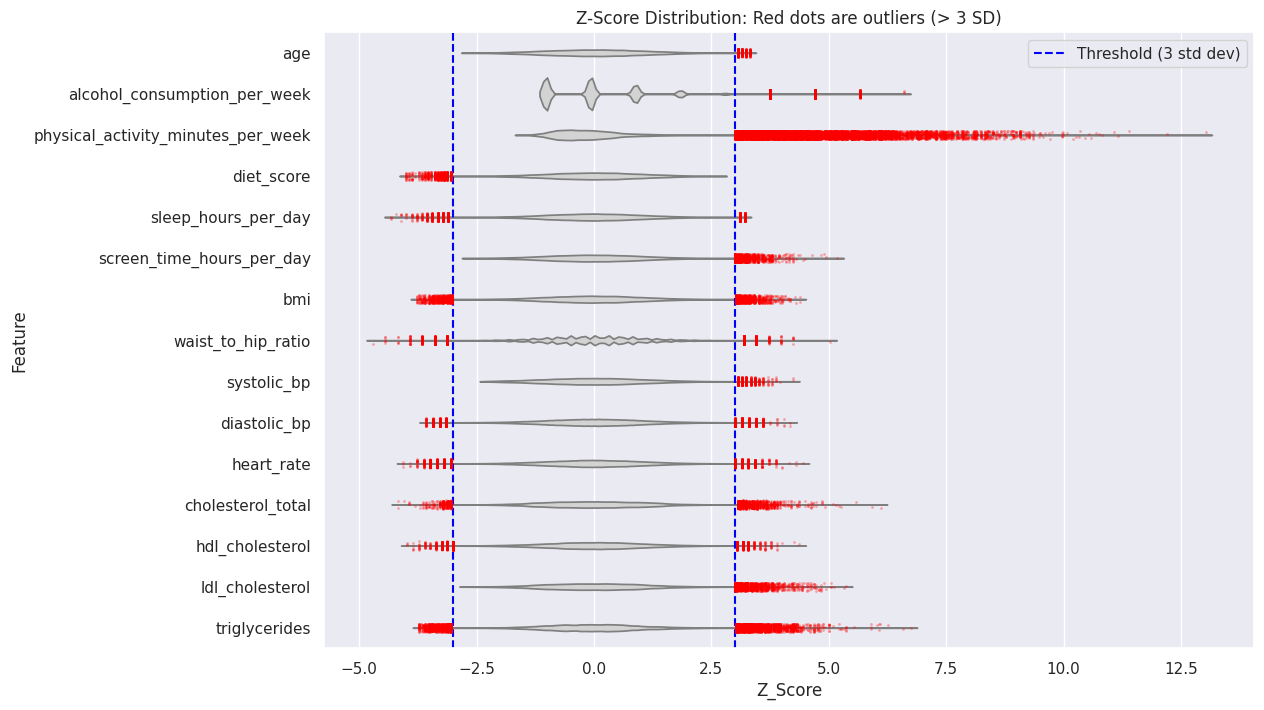

In [7]:

# Melt the Z-score dataframe for plotting
df_z_melted = df_zscore.melt(var_name='Feature', value_name='Z_Score')

plt.figure(figsize=(12, 8))
# We use a violin plot here because it shows the density of Z-scores beautifully
sns.violinplot(x='Z_Score', y='Feature', data=df_z_melted, inner=None, color='lightgray')

# Add strip plot to show the extreme outliers (filtered for readability)
# We only plot points with Z-score > 3 or < -3 to keep it clean
extreme_outliers = df_z_melted[(df_z_melted['Z_Score'] > 3) | (df_z_melted['Z_Score'] < -3)]
sns.stripplot(x='Z_Score', y='Feature', data=extreme_outliers, color='red', size=2, alpha=0.3)

plt.axvline(x=3, color='blue', linestyle='--', label='Threshold (3 std dev)')
plt.axvline(x=-3, color='blue', linestyle='--')
plt.title("Z-Score Distribution: Red dots are outliers (> 3 SD)")
plt.legend()
plt.show()


In [8]:
# Count how many people are beyond 3 Standard Deviations
for col in num_cols:
    outlier_count = (np.abs(stats.zscore(data[col])) > 3).sum()
    percentage = (outlier_count / len(data)) * 100
    print(f"{col}: {outlier_count} outliers ({percentage:.2f}%)")


age: 347 outliers (0.05%)
alcohol_consumption_per_week: 3237 outliers (0.46%)
physical_activity_minutes_per_week: 13808 outliers (1.97%)
diet_score: 795 outliers (0.11%)
sleep_hours_per_day: 1285 outliers (0.18%)
screen_time_hours_per_day: 1260 outliers (0.18%)
bmi: 1724 outliers (0.25%)
waist_to_hip_ratio: 1704 outliers (0.24%)
systolic_bp: 565 outliers (0.08%)
diastolic_bp: 1632 outliers (0.23%)
heart_rate: 1797 outliers (0.26%)
cholesterol_total: 1272 outliers (0.18%)
hdl_cholesterol: 1308 outliers (0.19%)
ldl_cholesterol: 1712 outliers (0.24%)
triglycerides: 4062 outliers (0.58%)


What should you do? (The Strategy)
For a dataset of 700,000 rows, do not delete these rows. 14,000 rows is too much data to throw away. Instead, use one of these three professional techniques:

Strategy A: Capping (Winsorization) - Highly Recommended
Instead of deleting the person who exercises 747 minutes, you "cap" them at the 99th percentile (e.g., 400 minutes). This keeps the person in your dataset but stops them from "pulling" the math too far.

Strategy B: Log Transformation
For variables like physical_activity or triglycerides where the Z-score is huge, a Log Transformation "shrinks" the distance between the outliers and the mean.

# Cap Physical Activity at the 99th percentile
upper_limit = data['physical_activity_minutes_per_week'].quantile(0.99)
data['physical_activity_minutes_per_week'] = data['physical_activity_minutes_per_week'].clip(upper=upper_limit)

In [9]:
# Log transform makes the 'tail' much shorter and for KAN 
data['log_physical_activity'] = np.log1p(data['physical_activity_minutes_per_week'])
data.head()

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,...,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes,log_physical_activity
0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,70,...,Hispanic,Highschool,Lower-Middle,Current,Employed,0,0,0,1.0,3.828641
1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,77,...,White,Highschool,Upper-Middle,Never,Employed,0,0,0,1.0,4.304065
2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,89,...,Hispanic,Highschool,Lower-Middle,Never,Retired,0,0,0,0.0,5.068904
3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,69,...,White,Highschool,Lower-Middle,Current,Employed,0,1,0,1.0,4.356709
4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,60,...,White,Highschool,Upper-Middle,Never,Retired,0,1,0,1.0,4.025352


Distribution and correlation to see what features are related to diagnosed diabetes by using correlation matrix and shits
#lets do beta target encoding

In [10]:
print(data.columns.tolist())



['age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 'gender', 'ethnicity', 'education_level', 'income_level', 'smoking_status', 'employment_status', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history', 'diagnosed_diabetes', 'log_physical_activity']


In [11]:

# 1. DEFINE YOUR TARGET
target_column = 'diagnosed_diabetes'

# 2. ENSURE TARGET IS NUMERIC (Critical for Target Encoding)
# If your data is already 0/1, this line won't hurt. 
# If it is 'Yes'/'No', this fixes it.
binary_map = {'Yes': 1, 'No': 0, 'Positive': 1, 'Negative': 0, 'Male': 1, 'Female': 0} 
# Note: Check your actual values. If they are already 0/1, skip the map.
if data[target_column].dtype == 'object':
    data[target_column] = data[target_column].map(binary_map)

# 3. IDENTIFY CATEGORICAL COLUMNS
# Based on your list, these are the ones that need Beta Encoding:
cat_cols = [
    'gender', 
    'ethnicity', 
    'education_level', 
    'income_level', 
    'smoking_status', 
    'employment_status',
    # These might be binary strings (Yes/No). If so, encode them too!
    'family_history_diabetes', 
    'hypertension_history', 
    'cardiovascular_history'
]

# 4. APPLY BETA TARGET ENCODING
print(f"Target is: {target_column}")

for col in cat_cols:
    # Check if column actually exists to prevent errors
    if col in data.columns:
        print(f"Encoding {col}...")
        
        # 1. Compute Global Mean of the Target (e.g., overall diabetes rate)
        global_mean = data[target_column].mean()
        
        # 2. Compute Aggregates per category
        agg = data.groupby(col)[target_column].agg(['count', 'mean'])
        counts = agg['count']
        means = agg['mean']
        
        # 3. Bayesian Smoothing (The "Beta" part)
        min_samples_leaf = 20
        smoothing = 10
        smooth = 1 / (1 + np.exp(-(counts - min_samples_leaf) / smoothing))
        
        # 4. Calculate the mapping
        encoding_map = global_mean * (1 - smooth) + means * smooth
        
        # 5. Map and Replace
        # We create a new column, fill NaNs with global average, and drop old one
        data[col + '_encoded'] = data[col].map(encoding_map)
        data[col + '_encoded'] = data[col + '_encoded'].fillna(global_mean)
        data = data.drop(columns=[col])

print("Encoding Complete. Data is ready for KAN/XGBoost.")
print(data.head())


Target is: diagnosed_diabetes
Encoding gender...
Encoding ethnicity...
Encoding education_level...
Encoding income_level...
Encoding smoking_status...
Encoding employment_status...
Encoding family_history_diabetes...
Encoding hypertension_history...
Encoding cardiovascular_history...
Encoding Complete. Data is ready for KAN/XGBoost.
   age  alcohol_consumption_per_week  physical_activity_minutes_per_week  \
0   31                             1                                  45   
1   50                             2                                  73   
2   32                             3                                 158   
3   54                             3                                  77   
4   54                             1                                  55   

   diet_score  sleep_hours_per_day  screen_time_hours_per_day   bmi  \
0         7.7                  6.8                        6.1  33.4   
1         5.7                  6.5                        5.8  23.

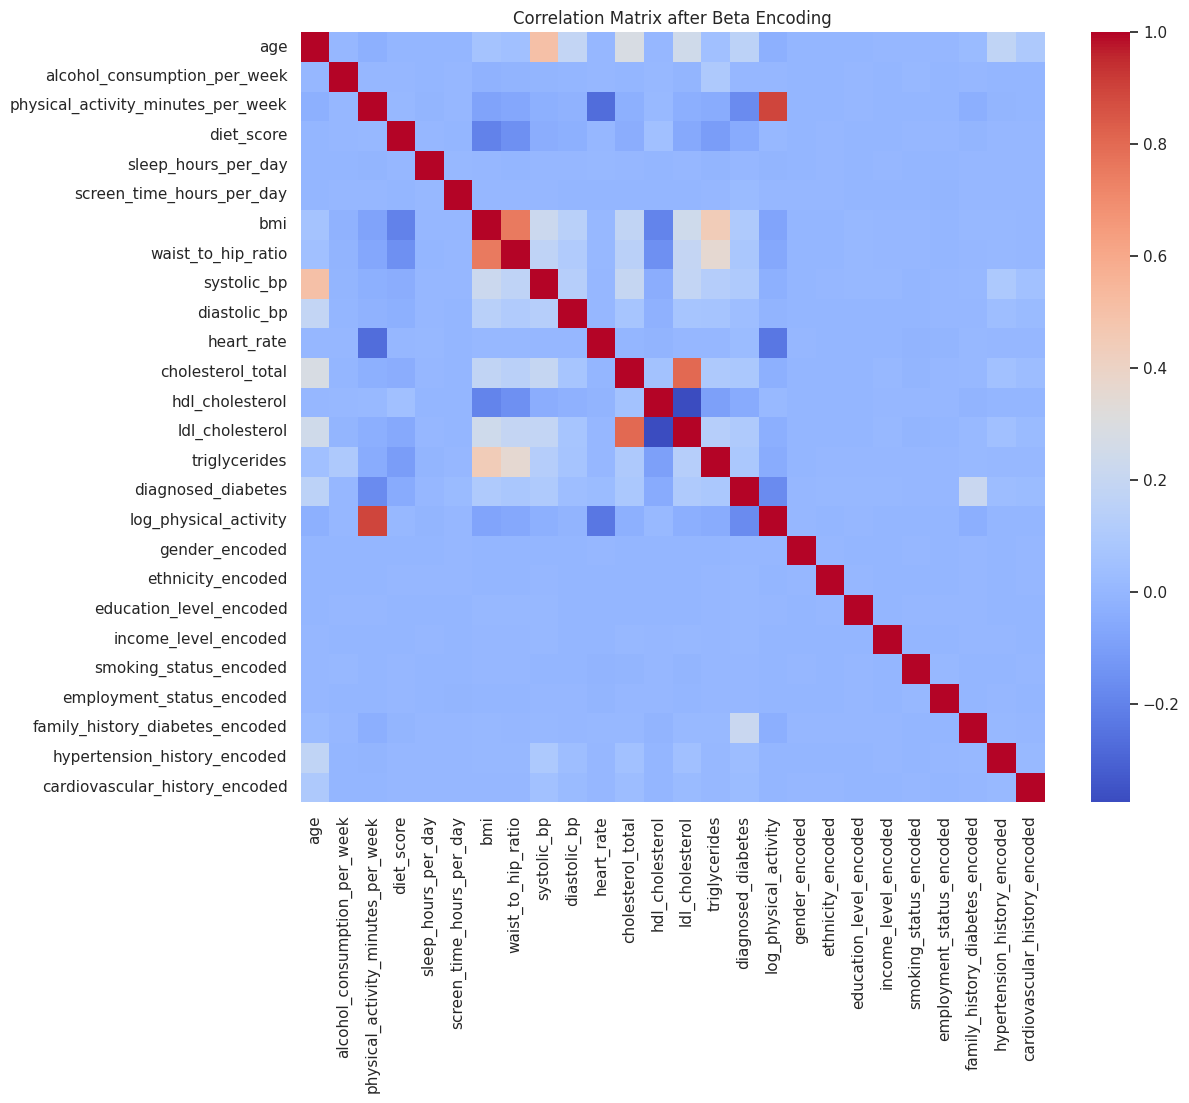

diagnosed_diabetes                 1.000000
family_history_diabetes_encoded    0.211064
age                                0.161162
systolic_bp                        0.107132
bmi                                0.105580
ldl_cholesterol                    0.102771
triglycerides                      0.090635
cholesterol_total                  0.088112
waist_to_hip_ratio                 0.081050
diastolic_bp                       0.036271
Name: diagnosed_diabetes, dtype: float64


In [12]:
#we also want to delete useless feature such as id and shit


# Calculate correlation matrix
corr_matrix = data.corr()

# Optional: Plot it nicely
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.title("Correlation Matrix after Beta Encoding")
plt.show()

# Show top correlations with target
print(corr_matrix[target_column].sort_values(ascending=False).head(10))


In [13]:
import xgboost as xgb
import torch
from kan import KAN
from sklearn.preprocessing import StandardScaler

In [14]:
# 1. LOAD DATA
train = pd.read_csv('/kaggle/input/competitions/playground-series-s5e12/train.csv')
test = pd.read_csv('/kaggle/input/competitions/playground-series-s5e12/test.csv')
submission = pd.read_csv('/kaggle/input/competitions/playground-series-s5e12/sample_submission.csv') # Usually provided

# Define Target and ID columns
target_col = 'diagnosed_diabetes'
id_col = 'id' # Replace with actual ID column name if different
# ---------------------------------------------------------
# STEP 0: APPLY LOG TRANSFORM (To both Train and Test!)
# ---------------------------------------------------------
print("Applying Log Transforms...")

# Apply to TRAIN
# Check if the column exists first to avoid errors
if 'physical_activity_minutes_per_week' in train.columns:
    train['log_physical_activity'] = np.log1p(train['physical_activity_minutes_per_week'])
    # Optional: Drop the original if it's too skewed, 
    # but XGBoost often likes having both the raw and log versions.
    # train.drop(columns=['physical_activity_minutes_per_week'], inplace=True) 

# Apply to TEST (MUST DO THIS)
if 'physical_activity_minutes_per_week' in test.columns:
    test['log_physical_activity'] = np.log1p(test['physical_activity_minutes_per_week'])
    # test.drop(columns=['physical_activity_minutes_per_week'], inplace=True)

# 2. HANDLE TARGET ENCODING (Crucial Step)
# ---------------------------------------------------------
# We must encode TEST data using the map learned from TRAIN data.

cat_cols = [
    'gender', 'ethnicity', 'education_level', 'income_level', 
    'smoking_status', 'employment_status', 
    'family_history_diabetes', 'hypertension_history', 'cardiovascular_history'
]

# Ensure target is numeric (0/1)
if train[target_col].dtype == 'object':
    binary_map = {'Yes': 1, 'No': 0, 'Positive': 1, 'Negative': 0, 'Male': 1, 'Female': 0}
    train[target_col] = train[target_col].map(binary_map)

print("Starting Beta Target Encoding...")

for col in cat_cols:
    if col in train.columns:
        # A. Calculate Mapping on TRAIN
        global_mean = train[target_col].mean()
        agg = train.groupby(col)[target_col].agg(['count', 'mean'])
        counts = agg['count']
        means = agg['mean']
        
        # Beta Smoothing
        min_samples_leaf = 20
        smoothing = 10
        smooth = 1 / (1 + np.exp(-(counts - min_samples_leaf) / smoothing))
        encoding_map = global_mean * (1 - smooth) + means * smooth
        
        # B. Apply to TRAIN
        new_col = col + '_encoded'
        train[new_col] = train[col].map(encoding_map).fillna(global_mean)
        
        # C. Apply to TEST (Using the map from Train!)
        test[new_col] = test[col].map(encoding_map).fillna(global_mean)
        
        # Drop original columns
        train.drop(columns=[col], inplace=True)
        test.drop(columns=[col], inplace=True)

# Drop ID columns if they exist (they are useless for prediction)
train_ids = train[id_col]
test_ids = test[id_col]
train.drop(columns=[id_col], inplace=True, errors='ignore')
test.drop(columns=[id_col], inplace=True, errors='ignore')

print("Data aligned.")

Applying Log Transforms...
Starting Beta Target Encoding...
Data aligned.


In [15]:
train.head()


,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,...,log_physical_activity,gender_encoded,ethnicity_encoded,education_level_encoded,income_level_encoded,smoking_status_encoded,employment_status_encoded,family_history_diabetes_encoded,hypertension_history_encoded,cardiovascular_history_encoded
0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,70,...,3.828641,0.622205,0.616314,0.621462,0.626835,0.623124,0.624643,0.580433,0.616444,0.621175
1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,77,...,4.304065,0.622205,0.624105,0.621462,0.620420,0.622911,0.624643,0.580433,0.616444,0.621175
2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,89,...,5.068904,0.624294,0.616314,0.621462,0.626835,0.622911,0.618058,0.580433,0.616444,0.621175
3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,69,...,4.356709,0.622205,0.624105,0.621462,0.626835,0.623124,0.624643,0.580433,0.654094,0.621175
4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,60,...,4.025352,0.624294,0.624105,0.621462,0.620420,0.622911,0.618058,0.580433,0.654094,0.621175


 Feature Engineering with KAN

 Explanation of Settings
1. width=[input_dim, 5, 1]:
We have input_dim features coming in.
The 5 in the middle means we allow the KAN to create 5 distinct new formulas (combinations of your inputs) before summing them up. This is where the "interaction" happens (e.g., maybe it finds 
B
M
I
/
log
⁡
(
A
g
e
)
BMI/log(Age)).
2. grid=3, k=3:
This controls how complex the curves can be. Keep these numbers low (3 or 5) for feature engineering. If they are too high, the KAN will just memorize the data (overfitting) instead of finding a general formula.
3. lamb=0.01:
This is regularization (L1 penalty). It encourages the KAN to use fewer inputs if possible, making the resulting feature cleaner.
4. auto_symbolic:
This is crucial. Without this, the KAN is just a black box. With this, the KAN snaps its internal weights to actual math functions, which makes the feature much more robust when you pass it to XGBoost.

In [16]:
# 3. PREPARE FOR KAN
# ---------------------------------------------------------
X = train.drop(columns=[target_col])
y = train[target_col]
X_test_final = test # This has same columns as X now

# Scale Data (KAN needs this)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test_final) # Use transform, not fit!

# Convert to Tensors
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y.values, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

# 4. TRAIN KAN (On a subset for speed)
# ---------------------------------------------------------
print("Training KAN...")
train_size = 50000 
indices = torch.randperm(len(X_tensor))[:train_size]
X_train_kan = X_tensor[indices]
y_train_kan = y_tensor[indices]

# Define Dataset
dataset = {
    'train_input': X_train_kan,
    'train_label': y_train_kan,
    'test_input': X_train_kan, 
    'test_label': y_train_kan
}

# Init Model
model = KAN(width=[X.shape[1], 5, 1], grid=3, k=3, seed=42)

# Standard Training (Manual loop to avoid errors)
optimizer = torch.optim.LBFGS(model.parameters(), lr=1.0, history_size=10, line_search_fn="strong_wolfe")

def closure():
    optimizer.zero_grad()
    loss = torch.nn.MSELoss()(model(X_train_kan), y_train_kan)
    loss.backward()
    return loss

for epoch in range(15):
    optimizer.step(closure)
    if epoch % 5 == 0: print(f"KAN Epoch {epoch}")

# 5. GENERATE FEATURE FOR TRAIN AND TEST
# ---------------------------------------------------------
with torch.no_grad():
    kan_feat_train = model(X_tensor).numpy()
    kan_feat_test = model(X_test_tensor).numpy()

# Add to Dataframes
train['kan_feature'] = kan_feat_train
test['kan_feature'] = kan_feat_test

print("KAN Feature added to Train and Test.")




Training KAN...
checkpoint directory created: ./model
saving model version 0.0
KAN Epoch 0
KAN Epoch 5
KAN Epoch 10
KAN Feature added to Train and Test.


In [17]:
import xgboost as xgb
from sklearn.calibration import CalibratedClassifierCV
import pandas as pd

# ---------------------------------------------------------
# 1. FIX DATA ALIGNMENT
# ---------------------------------------------------------

# Ensure 'kan_feature' exists in the original 'train' dataframe
# (If you ran the KAN code earlier, it might be in a variable called 'kan_feat_train')

# If 'kan_feature' is missing from train but you have it in a numpy array:
if 'kan_feature' not in train.columns and 'kan_feat_train' in locals():
    train['kan_feature'] = kan_feat_train

# RE-DEFINE X AND y TO INCLUDE THE KAN FEATURE
target_col = 'diagnosed_diabetes'
X_train = train.drop(columns=[target_col])
y_train = train[target_col]

# Ensure Test has the same columns
X_test = test # This should already have 'kan_feature' from your previous steps

# DOUBLE CHECK SHAPES (They must match now!)
print(f"Training shape: {X_train.shape}")
print(f"Testing shape:  {X_test.shape}")

if X_train.shape[1] != X_test.shape[1]:
    print("CRITICAL ERROR: Column counts still don't match!")
    print("Train cols:", X_train.columns.tolist())
    print("Test cols:", X_test.columns.tolist())
    # Stop execution if they don't match
    raise ValueError("Fix columns before proceeding.")

# ---------------------------------------------------------
# 2. TRAIN CALIBRATED MODEL
# ---------------------------------------------------------
print("Initializing XGBoost...")
base_xgb = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist', 
    n_jobs=-1,
    eval_metric="logloss",
    random_state=42
)

print("Training Calibrated XGBoost (Isotonic)...")
calibrated_model = CalibratedClassifierCV(base_xgb, method='isotonic', cv=5)
calibrated_model.fit(X_train, y_train)

# ---------------------------------------------------------
# 3. PREDICT & SUBMIT
# ---------------------------------------------------------
print("Generating Predictions...")
final_preds = calibrated_model.predict_proba(X_test)[:, 1]

# Ensure we have IDs
if 'test_ids' not in locals():
    test_ids = pd.read_csv('test.csv')['id']

submission = pd.DataFrame({
    'id': test_ids, 
    'diagnosed_diabetes': final_preds
})

submission.to_csv('submission.csv', index=False)
print("Successfully saved as 'submission.csv'")




Training shape: (700000, 26)
Testing shape:  (300000, 26)
Initializing XGBoost...
Training Calibrated XGBoost (Isotonic)...
Generating Predictions...
Successfully saved as 'submission.csv'


In [18]:
#sbm = pd.read_csv('submission_kan_xgb.csv')
#sbm.head()

In [19]:
sb = pd.read_csv('submission_bayesian_calibrated.csv')
sb.head()

FileNotFoundError: [Errno 2] No such file or directory: 'submission_bayesian_calibrated.csv'